In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io.wavfile as wavfile
from scipy.signal import ShortTimeFFT, windows
from scipy.fft import fft
from sklearn.cluster import DBSCAN
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

In [12]:

def create_spectrogram(audio, fs):
    w_s = fs * 10
    std = w_s // 6
    w = windows.gaussian(w_s, std=std)
    hop = fs // 2
    N = len(audio) // fs # audio length [s]

    SFT = ShortTimeFFT(win=w, hop=hop, fs=fs, scale_to='magnitude')
    Sx = SFT.spectrogram(audio)
    Sx_dB = 10 * np.log10(Sx)

    freqs = np.arange(Sx.shape[0]) * fs / w_s
    band_mask = (99.8 <= freqs) & (freqs <= 100.2)
    Sx_dB_filtered = Sx_dB[band_mask, :]

    width = 6.4 * N / 490
    fig = plt.figure(frameon=False, figsize=(width, 4.8))
    ax = fig.add_axes([0, 0, 1, 1])
    plt.imshow(
        Sx_dB_filtered,
        origin='lower',
        aspect='auto',
        cmap='magma',
        interpolation='bilinear'
    )
    ax.axis('off')
    fig.canvas.draw()
    img = np.asarray(fig.canvas.buffer_rgba())
    plt.close(fig)
    return img, int(width*100)

def color_convert(c):
    r, g, b, _ = c
    lumination = int(0.2126*r + 0.7152*g + 0.0722*b)
    return lumination

def img2array(img):
    height, width, _= img.shape
    xx, yy = [], []
    for y in range(height-1, -1, -1):
        for x in range(0, width):
            xx.append(x)
            yy.append(y)
    cords = np.column_stack((xx, yy))
    img_flat = img.reshape(-1, 4)
    colors = [color_convert(tuple(row)) for row in img_flat]
    X = np.column_stack((cords, colors))
    return X

def remove_outliers_iqr(data, axis, outlier_axis=2):
    min = np.min(data[:, axis])
    max = np.max(data[:, axis])
    sums = 0
    for v in range(min, max+1):
        line_mask = data[:, axis] == v
        if np.sum(line_mask) > 0:
            q1, q3 = np.percentile(data[line_mask, outlier_axis], [25, 75])
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            outliers_mask = line_mask & ((data[:, outlier_axis] < lower_bound) | (data[:, outlier_axis] > upper_bound))
            sums += np.sum(outliers_mask)
            data = data[outliers_mask == False]
    return data

def remove_outliers_DBSCAN(data, eps, min_samples):
    metric = 'euclidean'
    model = DBSCAN(eps = eps, min_samples = min_samples, metric = metric)
    model.fit(data[:, [0, 1]])
    label_mask = model.labels_ != -1
    data = data[label_mask]
    return data

def filter(X):
    mean_color = X[:, 2].mean()
    X = X[X[:, 2] > mean_color * 1.1, :]
    return X

def clean(X):
    for _ in range(5):
        X = remove_outliers_iqr(X, 0, 2)
        X = remove_outliers_iqr(X, 1, 2)
        X = remove_outliers_iqr(X, 1, 0)
    return X
    
def average_frequency(X):
    time, indices = np.unique(X[:, 0], return_inverse = True)
    means = np.bincount(indices, weights=X[:, 1]) / np.bincount(indices)
    return pd.Series(means, index=time.astype(int))

def smooth_chart(enf_ts):
    ses_model = SimpleExpSmoothing(enf_ts, initialization_method='heuristic').fit(smoothing_level=0.08, optimized=False)
    S = ses_model.fittedvalues
    return S

def fill_missing(n, X):
    missing_idx = list(set(np.arange(n)) - set(X.index))
    for idx in missing_idx:
        X.loc[idx] = float('NaN')
    X = X.sort_index()
    X = X.interpolate(method="nearest", limit_direction="both")
    X = X.ffill().bfill()

    return X


In [13]:
from IPython.display import display

def visualize_signal(audio):
    fig, ax = plt.subplots(figsize=(6.4, 4.8))
    ax.plot(audio)
    ax.set_title('Audio')
    ax.set_xlabel('time')
    ax.set_ylabel('amplitude')
    display(fig)
    plt.close(fig)

def visualize_dft(audio, fs):
    N = len(audio)
    sigfft = fft(audio, n=N)
    abssigfft = np.abs(sigfft)
    freqs = np.fft.fftfreq(N, 1 / fs)

    fig, ax = plt.subplots(figsize=(6.4, 4.8))
    ax.plot(freqs[:N//2], abssigfft[:N//2])
    ax.set_xlim(95, 105)
    ax.set_ylim(0, 1e7)
    ax.set_title('DFT for audio')
    ax.set_xlabel('frequency')
    ax.set_ylabel('amplitude')
    display(fig)
    plt.close(fig)

def visualize_lumination(X):
    fig = plt.figure(figsize=(6.4, 4.8))
    plt.scatter(X[:, 0], X[:, 1], c=X[:, 2], s=2)
    plt.xlabel('time')
    plt.ylabel('frequency')
    plt.title('Spectrogram [lumination]')
    display(fig)
    plt.close(fig)

def visualize_filtering(X):
    fig = plt.figure(figsize=(6.4, 4.8))
    plt.scatter(X[:, 0], X[:, 1], c=X[:, 2], s=2)
    plt.xlabel('time')
    plt.ylabel('frequency')
    plt.title('Spectrogram [filtered]')
    display(fig)
    plt.close(fig)

def visualize_iqr(X_before, X_after):
    plt.ioff()

    title = ['before iqr', 'after iqr']
    for i, X in enumerate([X_before, X_after]):
        fig = plt.figure(figsize=(6.4*2, 4.8))

        ax1 = fig.add_subplot(121, projection='3d')
        ax2 = fig.add_subplot(122, projection='3d')

        ax1.scatter(X[:,0], X[:,1], X[:,2], c=X[:,2], cmap='viridis')
        ax1.view_init(elev=10, azim=360)
        ax1.set_zlim(160, 250)
        ax1.set_title(f'View 1 {title[i]}')

        ax2.scatter(X[:,0], X[:,1], X[:,2], c=X[:,2], cmap='viridis')
        ax2.view_init(elev=5, azim=270)
        ax2.set_zlim(160, 250)
        ax2.set_title(f'View 2 {title[i]}')

        fig.tight_layout()
        display(fig)
        fig.canvas.draw_idle()
        plt.close(fig)
        
    plt.ion()

def visualize_DBScan(X_before, X_after):
    title = ['before DBScan', 'after DBScan']

    fig, ax = plt.subplots(1, 2, figsize=(6.4*2, 4.8))
    for i, X in enumerate([X_before, X_after]):
        ax[i].scatter(X[:, 0], X[:, 1], c=X[:, 2], s=2)
        ax[i].set_xlabel('time')
        ax[i].set_ylabel('frequency')
        ax[i].set_title(title[i])
    display(fig)
    plt.close(fig)
    
# def visualize_smoothing_cmp(X, F):
#     enf_smoothed = smooth_chart(F)
#     enf_averaged = F.rolling(window=25, center=True, win_type='gaussian').mean(std=10)

#     fig, ax = plt.subplots(1, 3, figsize=(6.4*3, 4.8))
#     ax[0].scatter(X[:, 0], X[:, 1], c=X[:, 2], s=2)
#     ax[0].plot(enf_smoothed, c='black')
#     ax[0].set_xlabel('time')
#     ax[0].set_ylabel('frequency')

#     ax[1].scatter(X[:, 0], X[:, 1], c=X[:, 2], s=2)
#     ax[1].plot(enf_averaged, c='black')
#     ax[1].set_xlabel('time')
#     ax[1].set_ylabel('frequency')

#     ax[2].scatter(X[:, 0], X[:, 1], c=X[:, 2], s=2)
#     ax[2].plot(F, c='black')
#     ax[2].set_xlabel('time')
#     ax[2].set_ylabel('frequency')
#     plt.show()

def visualize_smoothing(X, F):
    enf_smoothed = smooth_chart(F)

    fig, ax = plt.subplots(1, 2, figsize=(6.4*2, 4.8))
    ax[0].scatter(X[:, 0], X[:, 1], c=X[:, 2], s=2)
    ax[0].plot(F, c='black')
    ax[0].set_xlabel('time')
    ax[0].set_ylabel('frequency')
    ax[0].set_title('raw')
    
    ax[1].scatter(X[:, 0], X[:, 1], c=X[:, 2], s=2)
    ax[1].plot(enf_smoothed, c='black')
    ax[1].set_xlabel('time')
    ax[1].set_ylabel('frequency')
    ax[1].set_title('exponential smoothing')
    plt.show()


In [14]:
def large_precompute(import_path, export_path, export_chunk_path="./precomp-data/h1-ref-day/chunks/"):
    fs, audio = wavfile.read(import_path)        
    N = len(audio)
    C = 2e2 #chunk size
    enf = pd.Series()

    for i in range((N+C-1) // C):
        print(f'Precomputing chunk {i}')
        audio_part = audio[i*C:(i+1)*C]
        img, width = create_spectrogram(audio_part, fs)
        X = img2array(img)

        X_filtered = filter(X.copy())
        X_cleaned = clean(X_filtered.copy())
        X_grouped = remove_outliers_DBSCAN(X_cleaned.copy(), 11, 100)
        X_averaged = average_frequency(X_grouped.copy())
        X_filled = fill_missing(width, X_averaged.copy())

        enf_smoothed = smooth_chart(X_filled)
        enf_smoothed.to_csv(f'{export_chunk_path}/chunk_{i}') # backup for precomputed chunk

        enf = pd.concat([enf, enf_smoothed], ignore_index=True)
    
    enf.to_csv(export_path)

In [15]:
# takes 30s
def small_precompute(import_path, export_path):
    fs, audio = wavfile.read(import_path)        
    N = len(audio)
    visualize_signal(audio)
    visualize_dft(audio, fs)

    img, width = create_spectrogram(audio, fs)
    X = img2array(img)
    visualize_lumination(X)
    
    X_filtered = filter(X.copy())
    visualize_filtering(X_filtered)

    X_cleaned = clean(X_filtered.copy())
    visualize_iqr(X_filtered, X_cleaned)
    
    X_grouped = remove_outliers_DBSCAN(X_cleaned.copy(), 11, 100)
    visualize_DBScan(X_cleaned, X_grouped)
    
    X_averaged = average_frequency(X_grouped.copy())
    X_filled = fill_missing(width, X_averaged.copy())

    enf_smoothed = smooth_chart(X_filled)
    enf_smoothed.to_csv(export_path)
    visualize_smoothing(X, X_filled)



In [16]:
def file_name(i, tail):
    name = ""
    if i < 10:
        name = '00' + f'{i}'
    elif i < 100:
        name = '0' + f'{i}'
    else:
        name = f'{i}'
    return name + tail

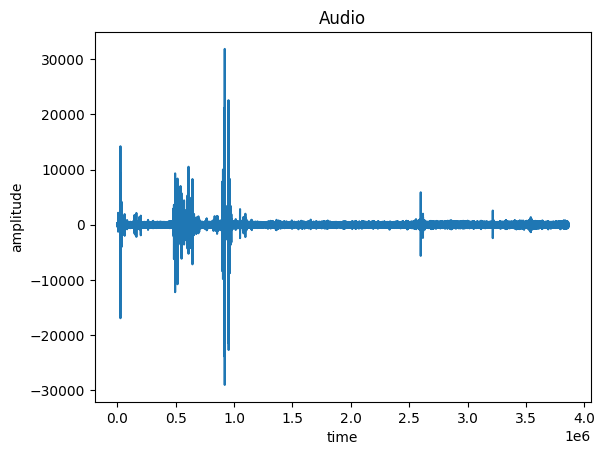

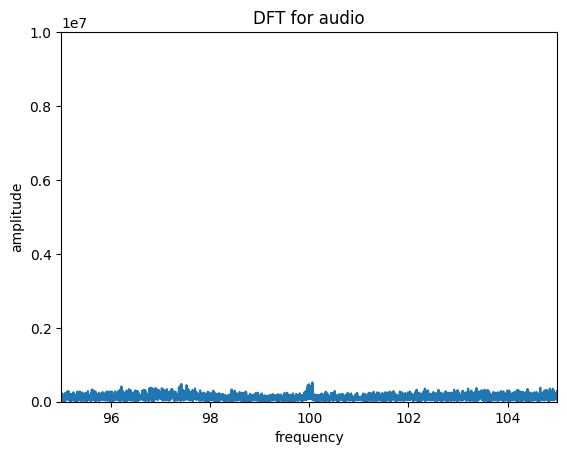

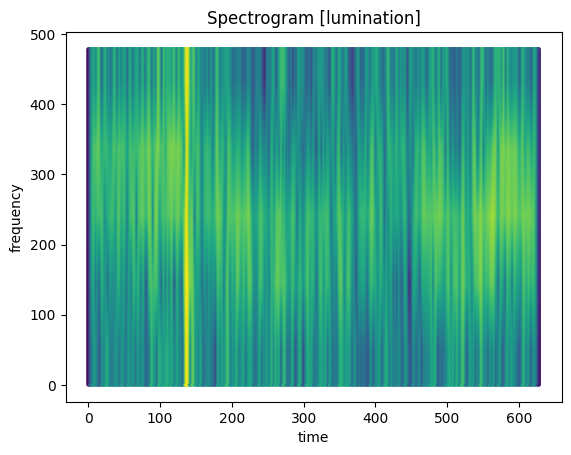

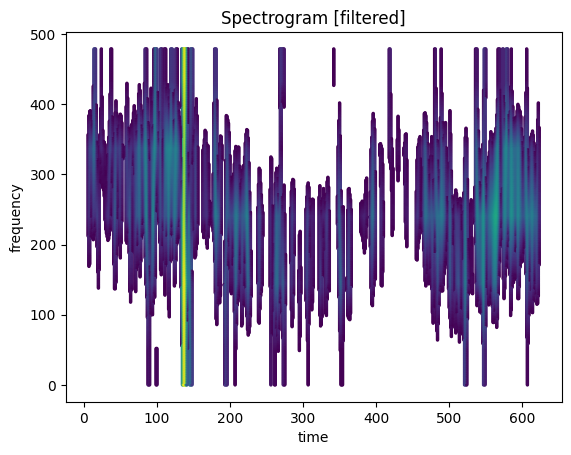

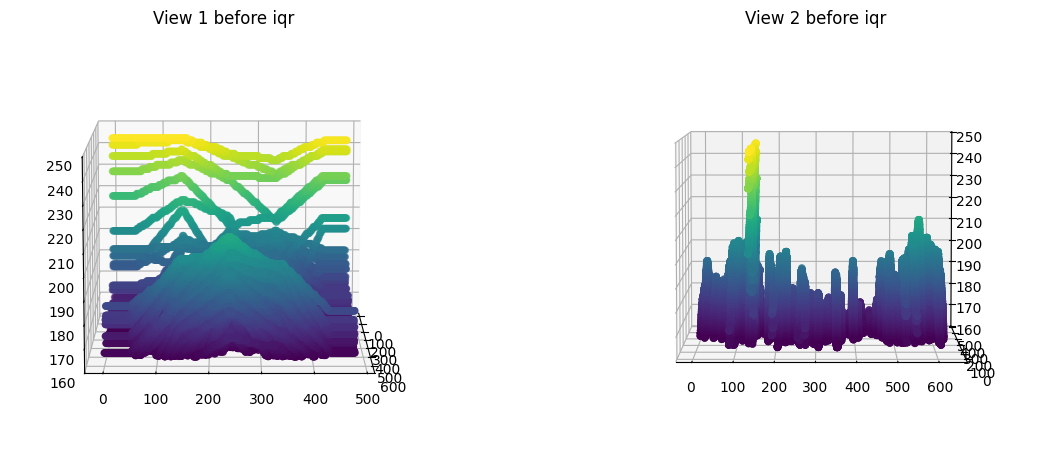

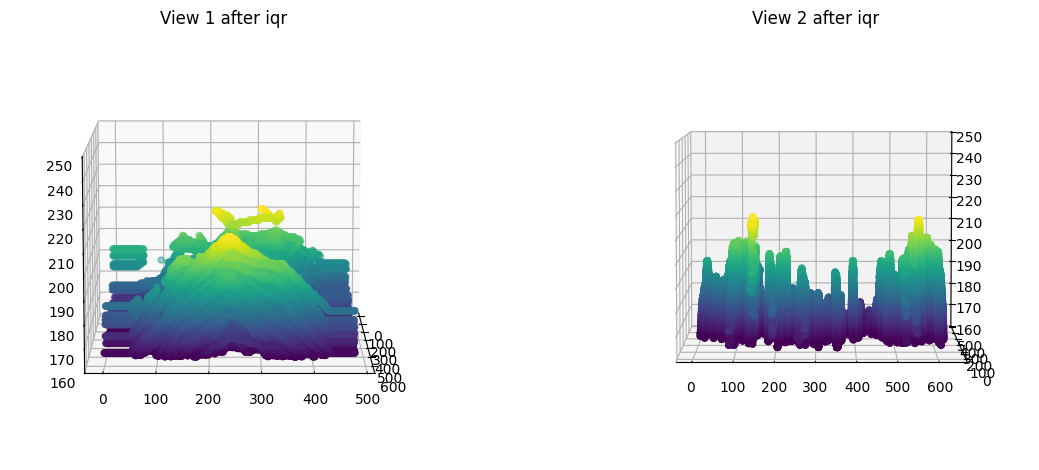

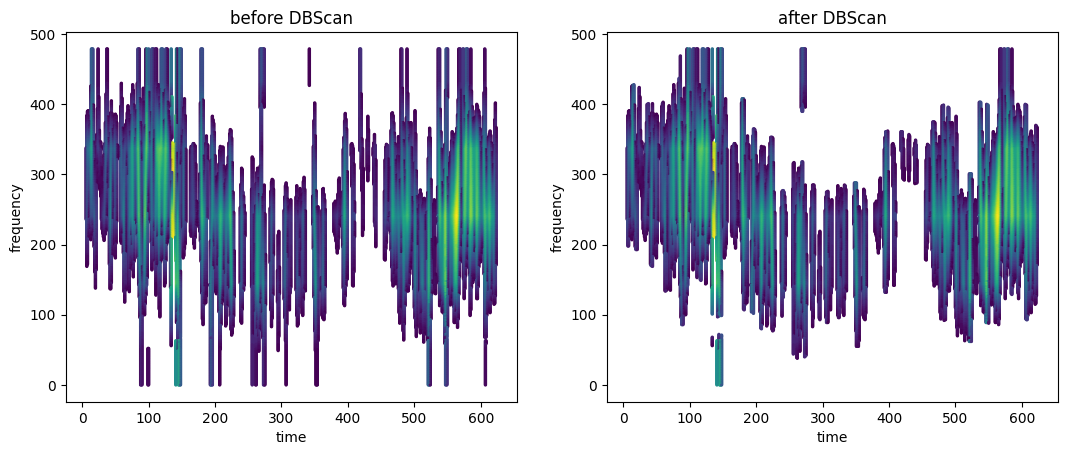

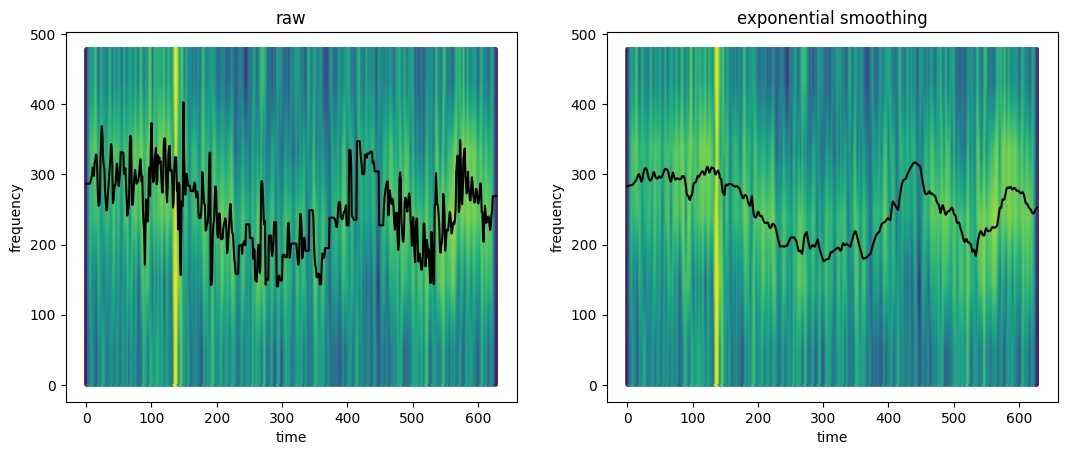

In [17]:
for i in range(1, 2):
    import_path = f"./data/h1/{file_name(i, '.wav')}"
    export_path = f"./precomp-data/h1/{file_name(i, '.csv')}"
    small_precompute(import_path, export_path)

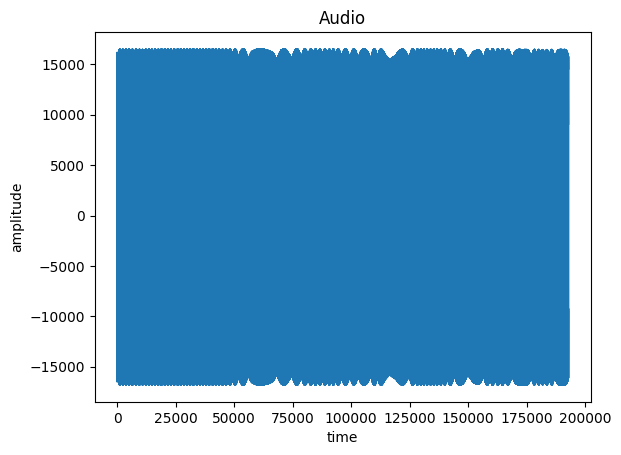

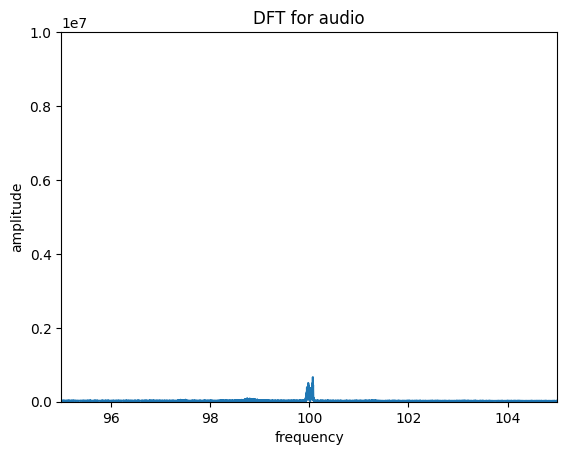

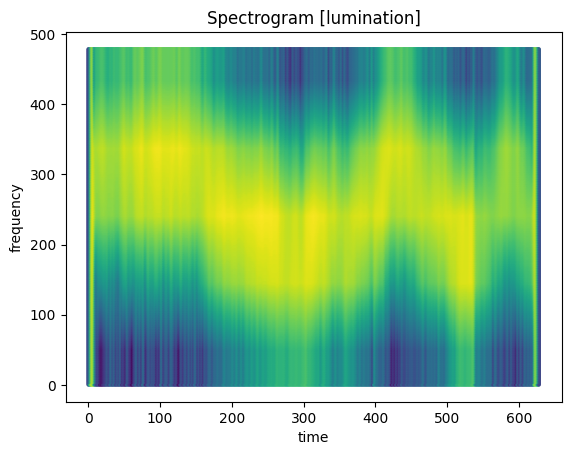

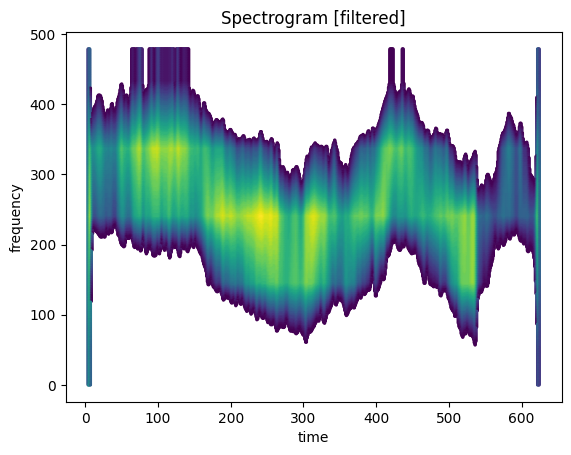

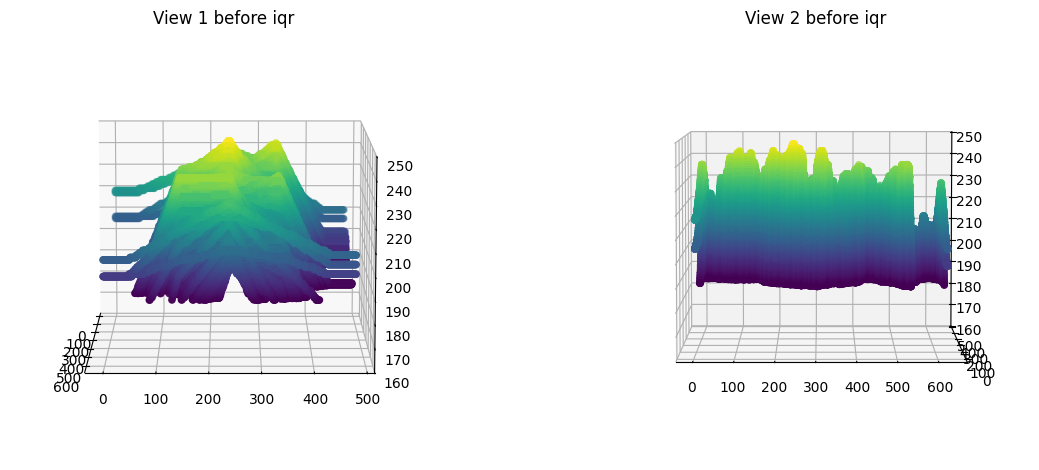

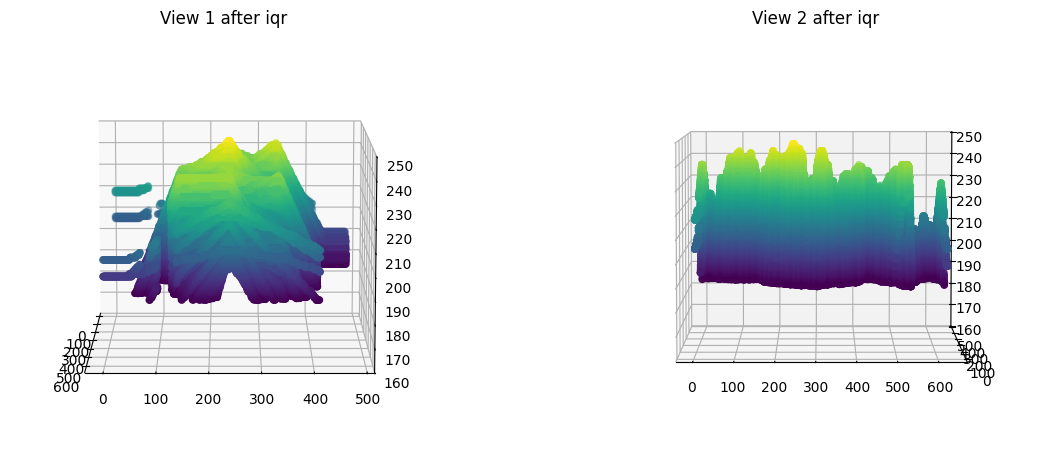

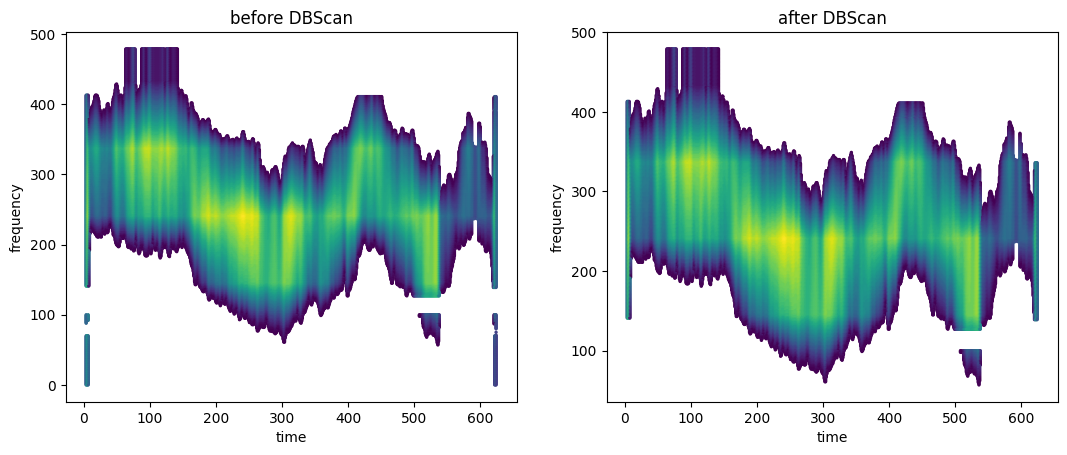

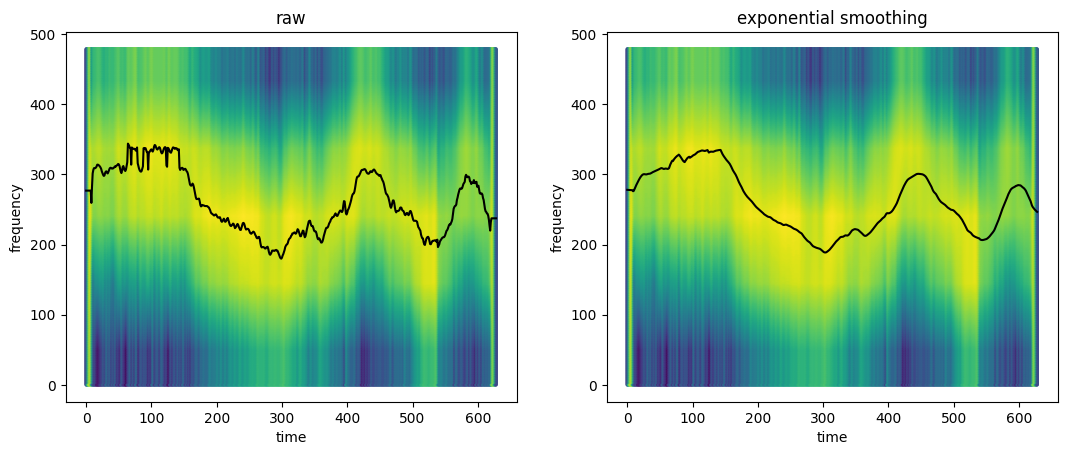

In [18]:
for i in range(1, 2):
    import_path = f"./data/h1-ref/{file_name(i, '_ref.wav')}"
    export_path = f"./precomp-data/h1-ref/{file_name(i, '.csv')}"
    small_precompute(import_path, export_path)

(0.0, 500.0)

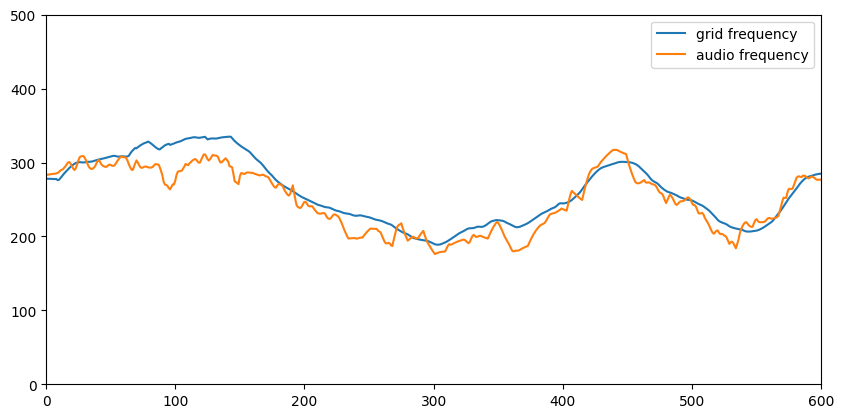

In [19]:
audio_freqs_list = []
grid_freqs_list = []

for i in range(1, 2):
    gf = pd.read_csv(f"./precomp-data/h1-ref/{file_name(i, '.csv')}", index_col=0) 
    af = pd.read_csv(f"./precomp-data/h1/{file_name(i, '.csv')}", index_col=0)
    grid_freqs_list.append(gf)
    audio_freqs_list.append(af)

grid_freqs = pd.concat(grid_freqs_list, ignore_index=True)
audio_freqs = pd.concat(audio_freqs_list, ignore_index=True)

plt.figure(figsize=(10, 4.8))
plt.plot(grid_freqs)
plt.plot(audio_freqs)
plt.legend(['grid frequency', 'audio frequency'])
plt.xlim(0, 600)
plt.ylim(0, 500)